## 18. Use a synthetic binary classification dataset with overlapping classes.
### a. Train a Logistic Regression model.
### b. Compare hard labels (threshold = 0.5) with probability outputs.
### c. Analyze prediction instability near the decision boundary.

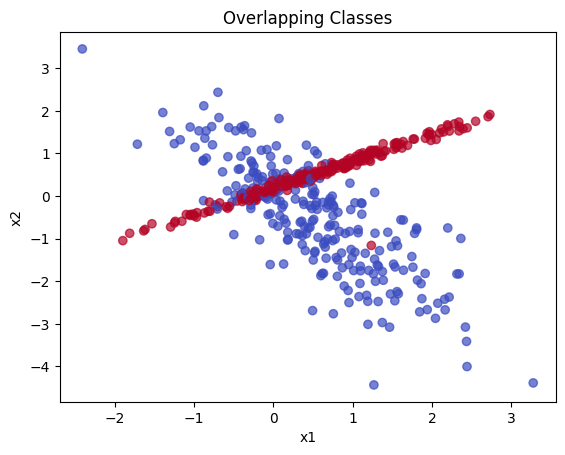

Probabilities near boundary: [0.50277566 0.50470689 0.48049264 0.46452498 0.51226502 0.52734334
 0.53935578 0.49995822 0.46847585 0.45912902]
Hard labels: [1 1 0 0 1 1 1 0 0 0]


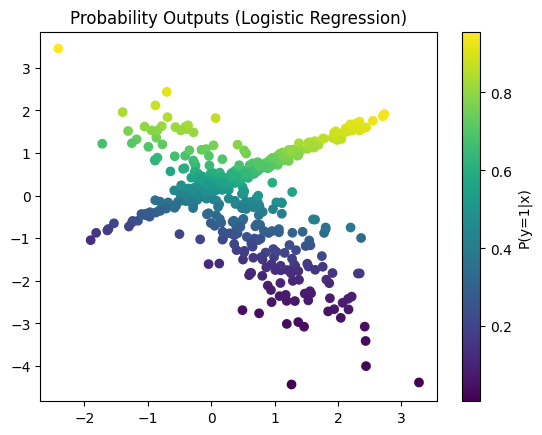

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.linear_model import LogisticRegression


np.random.seed(42)

X, y = make_classification(
    n_samples=500,
    n_features=2,
    n_redundant=0,
    n_clusters_per_class=1,
    class_sep=0.5   # strong overlap
)

plt.scatter(X[:,0], X[:,1], c=y, cmap="coolwarm", alpha=0.7)
plt.xlabel("x1")
plt.ylabel("x2")
plt.title("Overlapping Classes")
plt.show()


lr = LogisticRegression()
lr.fit(X, y)

proba = lr.predict_proba(X)[:, 1]
y_pred = (proba >= 0.5).astype(int)


boundary_points = np.abs(proba - 0.5) < 0.05

print("Probabilities near boundary:", proba[boundary_points][:10])
print("Hard labels:", y_pred[boundary_points][:10])


plt.scatter(X[:,0], X[:,1], c=proba, cmap="viridis")
plt.colorbar(label="P(y=1|x)")
plt.title("Probability Outputs (Logistic Regression)")
plt.show()


In datasets with overlapping classes, logistic regression produces probabilistic outputs that smoothly vary near the decision boundary, reflecting inherent uncertainty. Hard classification using a fixed threshold discards this uncertainty and leads to unstable predictions, where small perturbations in the input can cause abrupt label changes. Probability outputs therefore provide a more informative and reliable representation of model confidence in ambiguous regions.